In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
apps = pd.read_csv("Google_Play_Apps.csv")
reviews = pd.read_csv("Google_Play_Reviews.csv")

In [3]:
print("Apps dataset:")
print(apps.shape)

print("\nReviews dataset:")
print(reviews.shape)

Apps dataset:
(10841, 13)

Reviews dataset:
(64295, 5)


In [4]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [5]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [6]:
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [7]:
apps.duplicated().sum()

np.int64(483)

In [8]:
apps = apps.drop_duplicates()

In [9]:
apps.duplicated().sum()

np.int64(0)

In [10]:
apps["Rating"].describe()

count    8893.000000
mean        4.189542
std         0.545452
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64

In [11]:
apps["Rating"].value_counts().sort_index()

Rating
1.0       16
1.2        1
1.4        3
1.5        3
1.6        4
1.7        8
1.8        8
1.9       12
2.0       12
2.1        8
2.2       14
2.3       20
2.4       19
2.5       20
2.6       24
2.7       23
2.8       40
2.9       45
3.0       82
3.1       69
3.2       64
3.3      101
3.4      127
3.5      157
3.6      169
3.7      231
3.8      293
3.9      372
4.0      539
4.1      657
4.2      888
4.3     1016
4.4     1032
4.5      977
4.6      768
4.7      484
4.8      228
4.9       87
5.0      271
19.0       1
Name: count, dtype: int64

In [12]:
apps["Rating"] = apps["Rating"].fillna(apps["Rating"].median())

In [13]:
apps["Rating"].isnull().sum()

np.int64(0)

In [14]:
apps[apps[["Type", "Content Rating", "Current Ver", "Android Ver"]].isnull().any(axis=1)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55,2.7M,"5,000+",Free,0,Everyone,Art & Design,6-Jun-18,NaN,4.2 and up
1553,Market Update Helper,LIBRARIES_AND_DEMO,4.1,20145,11k,"1,000,000+",Free,0,Everyone,Libraries & Demo,12-Feb-13,NaN,1.5 and up
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11M,"1,000+",Paid,$1.49,Everyone,Personalization,20-Jul-18,4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2.1M,"10,000+",Free,0,Everyone,Personalization,27-Mar-18,1.1,NaN
6322,Virtual DJ Sound Mixer,TOOLS,4.2,4010,8.7M,"500,000+",Free,0,Everyone,Tools,10-May-17,NaN,4.0 and up
6803,BT Master,FAMILY,4.3,0,222k,100+,Free,0,Everyone,Education,6-Nov-16,NaN,1.6 and up
7333,Dots puzzle,FAMILY,4.0,179,14M,"50,000+",Paid,$0.99,Everyone,Puzzle,18-Apr-18,NaN,4.0 and up
7407,Calculate My IQ,FAMILY,4.3,44,7.2M,"10,000+",Free,0,Everyone,Entertainment,3-Apr-17,NaN,2.3 and up
7730,UFO-CQ,TOOLS,4.3,1,237k,10+,Paid,$0.99,Everyone,Tools,4-Jul-16,NaN,2.0 and up
9148,Command & Conquer: Rivals,FAMILY,4.3,0,Varies with device,0,NaN,0,Everyone 10+,Strategy,28-Jun-18,Varies with device,Varies with device


In [15]:
apps["Type"] = apps["Type"].fillna("Free")
apps["Content Rating"] = apps["Content Rating"].fillna("Unknown")
apps["Current Ver"] = apps["Current Ver"].fillna("Unknown")
apps["Android Ver"] = apps["Android Ver"].fillna("Unknown")

In [16]:
apps.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [17]:
apps["Installs"].head(10)

0        10,000+
1       500,000+
2     5,000,000+
3    50,000,000+
4       100,000+
5        50,000+
6        50,000+
7     1,000,000+
8     1,000,000+
9        10,000+
Name: Installs, dtype: str

In [19]:
apps[apps["Installs"] == "Free"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,Unknown,11-Feb-18,1.0.19,4.0 and up,Unknown


In [20]:
apps["Installs"] = apps["Installs"].replace("Free", np.nan)

apps["Installs"] = apps["Installs"].str.replace(",", "", regex=False)
apps["Installs"] = apps["Installs"].str.replace("+", "", regex=False)

apps["Installs"] = pd.to_numeric(apps["Installs"])

In [21]:
apps["Installs"].dtype

dtype('float64')

In [22]:
apps["Installs"].isnull().sum()

np.int64(1)

In [23]:
apps["Installs"] = apps["Installs"].fillna(apps["Installs"].median())

In [24]:
apps["Installs"].isnull().sum()

np.int64(0)

In [25]:
apps["Price"].head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: Price, dtype: str

In [26]:
apps["Price"].unique()[:20]

<StringArray>
[      '0',  '$4.99 ',  '$3.99 ',  '$6.99 ',  '$1.49 ',  '$2.99 ',  '$7.99 ',
  '$5.99 ',  '$3.49 ',  '$1.99 ',  '$9.99 ',  '$7.49 ',  '$0.99 ',  '$9.00 ',
  '$5.49 ', '$10.00 ', '$24.99 ', '$11.99 ', '$79.99 ', '$16.99 ']
Length: 20, dtype: str

In [27]:
apps["Price"] = apps["Price"].astype(str).str.replace("$", "", regex=False)
apps["Price"] = pd.to_numeric(apps["Price"], errors="coerce")

In [28]:
apps["Price"].dtype

dtype('float64')

In [29]:
apps["Category"].value_counts()

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

In [30]:
apps[apps["Category"] == "1.9"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",100000.0,0,NaN,Unknown,11-Feb-18,1.0.19,4.0 and up,Unknown


In [31]:
apps = apps[apps["Category"] != "1.9"]

In [32]:
apps["Category"].value_counts().tail()

Category
ART_AND_DESIGN    65
EVENTS            64
COMICS            60
PARENTING         60
BEAUTY            53
Name: count, dtype: int64

In [33]:
apps["Category"].value_counts()

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
Name: count, dtype: int64

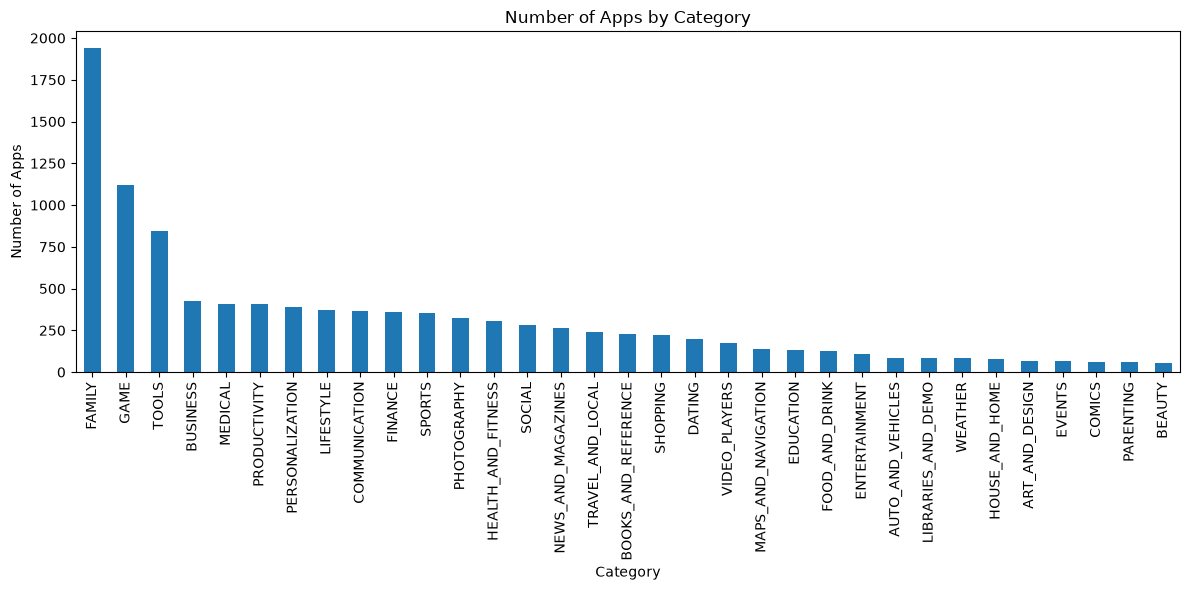

In [34]:
plt.figure(figsize=(12, 6))

apps["Category"].value_counts().plot(kind="bar")

plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

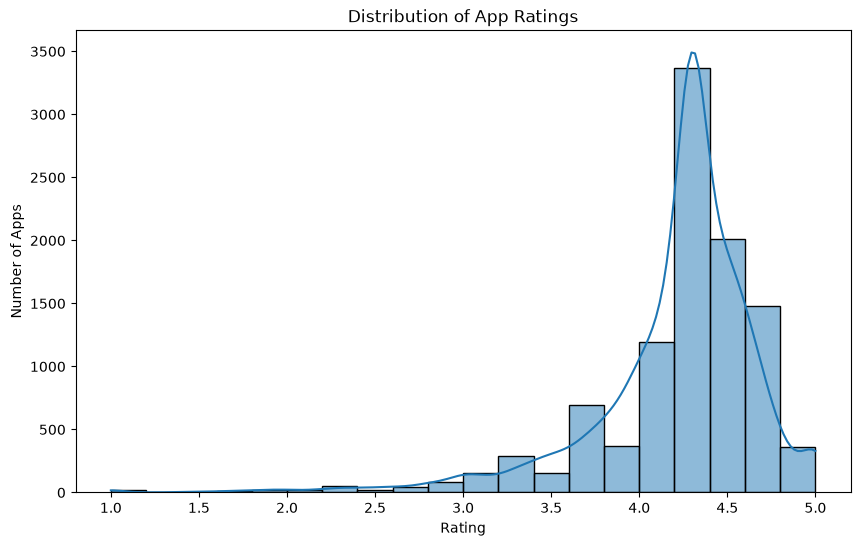

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(apps["Rating"], bins=20, kde=True)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

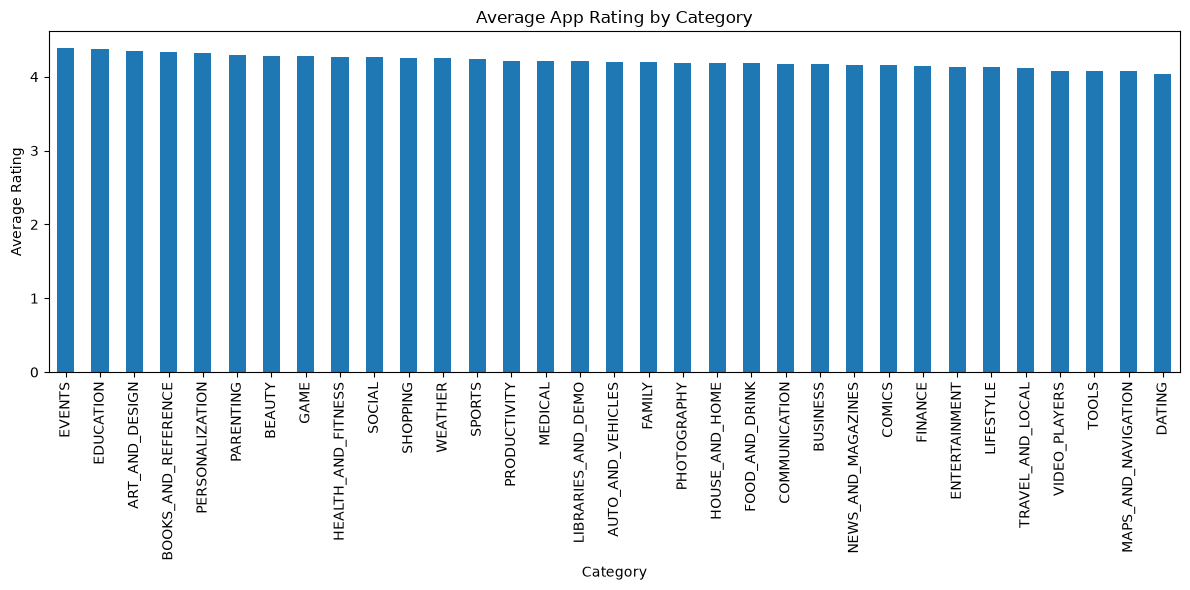

In [36]:
avg_rating = apps.groupby("Category")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

avg_rating.plot(kind="bar")

plt.title("Average App Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [37]:
category_rating = apps.groupby("Category")["Rating"].mean().sort_values(ascending=False)

category_rating

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.355385
BOOKS_AND_REFERENCE    4.336522
PERSONALIZATION        4.327062
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
SHOPPING               4.256250
WEATHER                4.248780
SPORTS                 4.239031
PRODUCTIVITY           4.219410
MEDICAL                4.212990
LIBRARIES_AND_DEMO     4.207059
AUTO_AND_VEHICLES      4.205882
FAMILY                 4.203757
PHOTOGRAPHY            4.189441
HOUSE_AND_HOME         4.185000
FOOD_AND_DRINK         4.183871
COMMUNICATION          4.175410
BUSINESS               4.175176
NEWS_AND_MAGAZINES     4.160985
COMICS                 4.160000
FINANCE                4.148056
ENTERTAINMENT          4.136036
LIFESTYLE              4.133244
TRAVEL_AND_LOCAL       4.121941
VIDEO_PLAYERS          4.084000
TOOLS                  4.080071

In [39]:
apps["Size"].head(10)

0     19M
1     14M
2    8.7M
3     25M
4    2.8M
5    5.6M
6     19M
7     29M
8     33M
9    3.1M
Name: Size, dtype: str

In [40]:
apps["Size"] = apps["Size"].str.replace("M", "", regex=False)
apps["Size"] = apps["Size"].str.replace("k", "", regex=False)

apps["Size"] = pd.to_numeric(apps["Size"], errors="coerce")

In [41]:
apps["Size"].head()

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64

In [42]:
apps["Size"].isnull().sum()

np.int64(1526)

In [43]:
apps[apps["Size"].isnull()]["Size"].head()

37   NaN
42   NaN
52   NaN
67   NaN
68   NaN
Name: Size, dtype: float64

In [44]:
original_size = pd.read_csv("Google_Play_Apps.csv")["Size"]

original_size.value_counts().head(10)

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
15M                    184
17M                    160
19M                    154
26M                    149
16M                    149
Name: count, dtype: int64

In [45]:
apps = apps.dropna(subset=["Size"])

In [46]:
apps["Size"].isnull().sum()

np.int64(0)

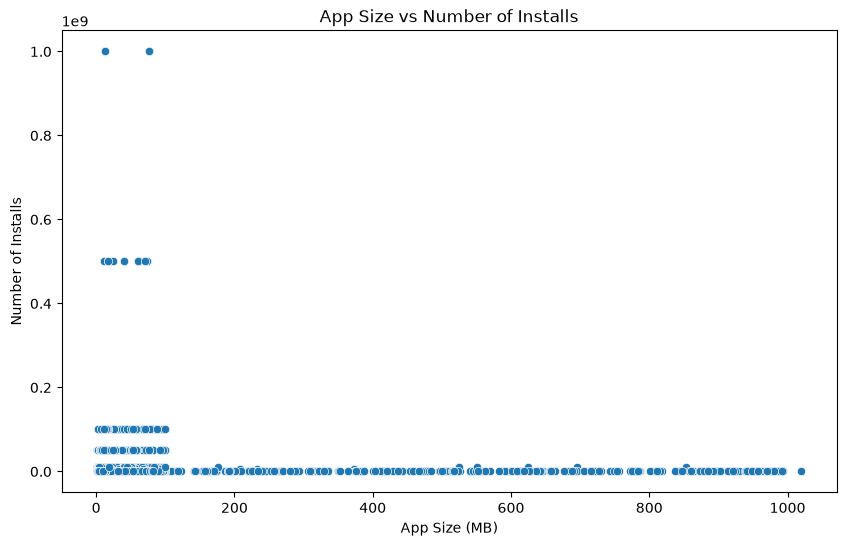

In [47]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=apps, x="Size", y="Installs")

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.show()

In [48]:
apps[["Size", "Installs"]].corr()

,Size,Installs
Size,1.000000,0.014729
Installs,0.014729,1.000000


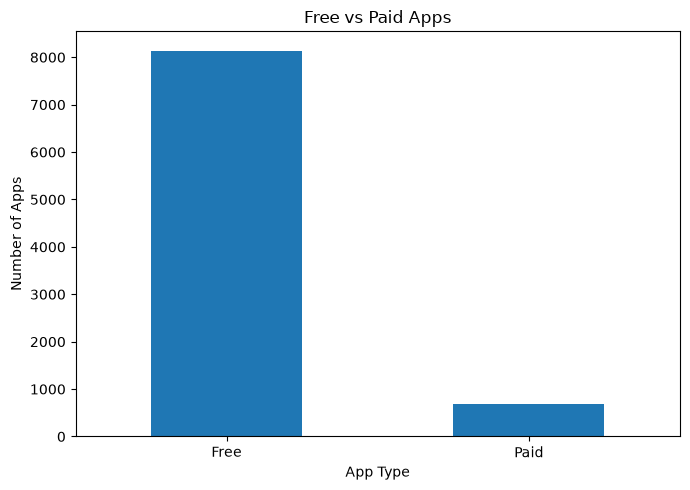

In [49]:
plt.figure(figsize=(7, 5))

apps["Type"].value_counts().plot(kind="bar")

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

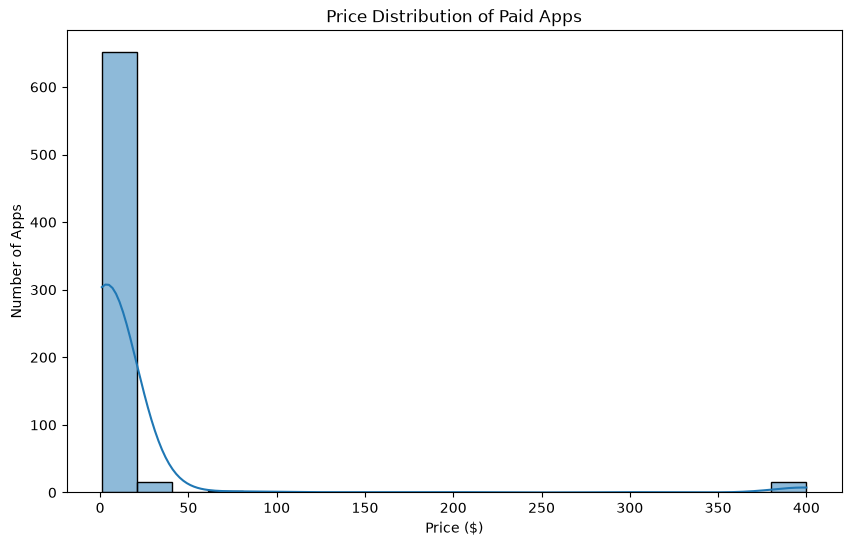

In [50]:
paid_apps = apps[apps["Type"] == "Paid"]

plt.figure(figsize=(10, 6))

sns.histplot(paid_apps["Price"], bins=20, kde=True)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.show()

In [51]:
paid_apps["Estimated_Revenue"] = paid_apps["Price"] * paid_apps["Installs"]

In [52]:
revenue_by_category = (
    paid_apps.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category

Category
LIFESTYLE              57554049.40
FAMILY                 44122005.86
GAME                   40389634.87
FINANCE                25726678.98
MEDICAL                 8100370.67
PHOTOGRAPHY             8053267.70
PERSONALIZATION         7129022.66
SPORTS                  3607711.95
PRODUCTIVITY            3192434.95
EDUCATION               2403980.00
TOOLS                   1580731.59
WEATHER                 1184885.00
BUSINESS                1049244.25
COMMUNICATION            805474.50
HEALTH_AND_FITNESS       728568.90
ENTERTAINMENT            299000.00
PARENTING                249500.00
FOOD_AND_DRINK           249500.00
TRAVEL_AND_LOCAL         232604.40
BOOKS_AND_REFERENCE       75276.74
MAPS_AND_NAVIGATION       41789.00
ART_AND_DESIGN            31840.00
SHOPPING                  30149.00
DATING                     8561.50
NEWS_AND_MAGAZINES         6445.00
SOCIAL                     5940.00
VIDEO_PLAYERS               990.00
AUTO_AND_VEHICLES           648.50
EVENTS     

In [53]:
reviews["Sentiment"].value_counts()

Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64

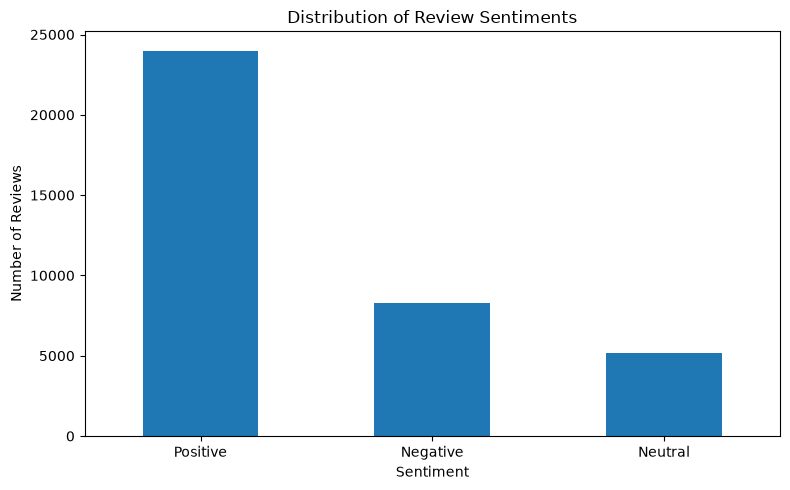

In [54]:
plt.figure(figsize=(8, 5))

reviews["Sentiment"].value_counts().plot(kind="bar")

plt.title("Distribution of Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [55]:
reviews_with_category = reviews.merge(
    apps[["App", "Category"]],
    on="App",
    how="left"
)

In [56]:
reviews_with_category[["App", "Category", "Sentiment"]].head()

,App,Category,Sentiment
0,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
1,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
2,10 Best Foods for You,HEALTH_AND_FITNESS,NaN
3,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
4,10 Best Foods for You,HEALTH_AND_FITNESS,Positive


In [57]:
sentiment_by_category = pd.crosstab(
    reviews_with_category["Category"],
    reviews_with_category["Sentiment"]
)

sentiment_by_category

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,58,54,233
AUTO_AND_VEHICLES,11,20,133
BEAUTY,57,83,162
BOOKS_AND_REFERENCE,23,52,200
BUSINESS,131,150,484
COMICS,0,4,6
COMMUNICATION,78,86,404
DATING,448,369,1392
EDUCATION,60,80,378


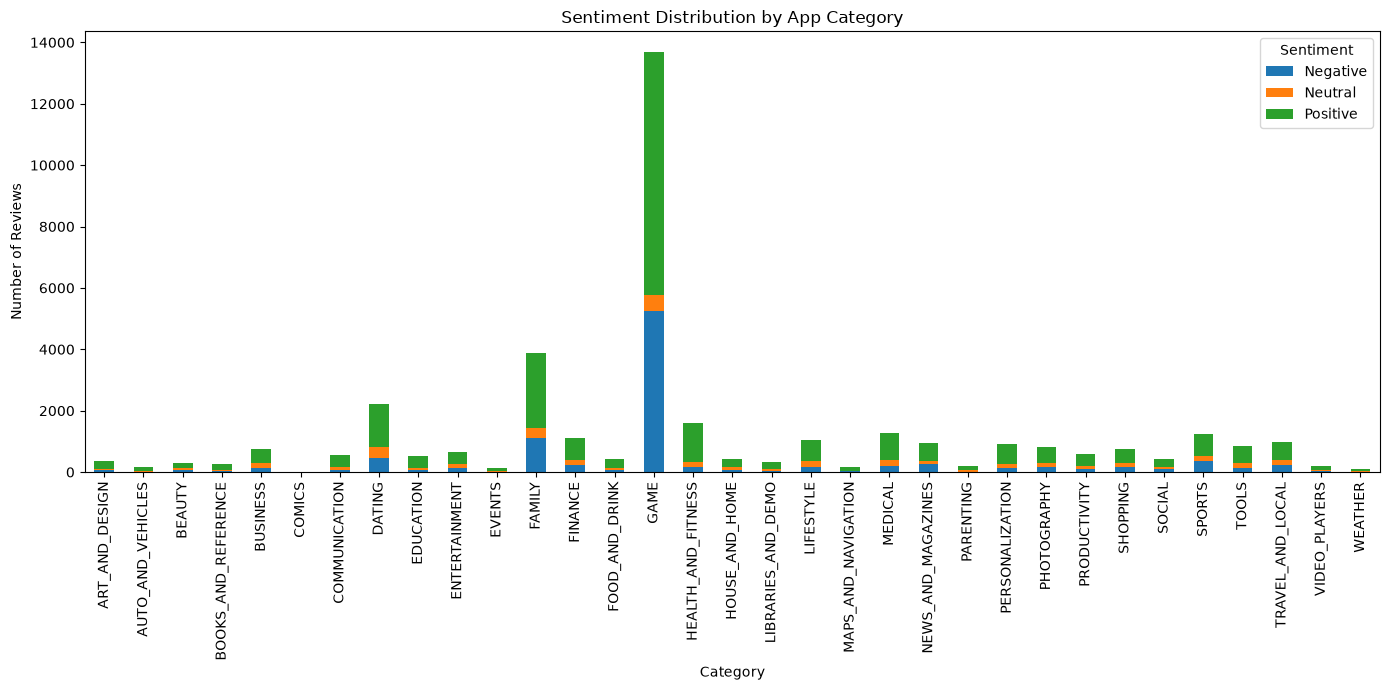

In [58]:
sentiment_by_category.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Sentiment Distribution by App Category")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [61]:
import sys
!{sys.executable} -m pip install plotly

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.1 MB 1.6 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.1 MB 1.6 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/9.1 MB 2.1 MB/s eta 0:00:04
   --------------- ------------------------ 3.4/9.1 MB 3.2 MB/s eta 0:00:02
   ---------------------------- ----------- 6.6/9.1 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------  8.9/9.1 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 5.9 MB/s  0:00:01


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [62]:
import plotly.express as px

In [63]:
fig = px.bar(
    category_rating.sort_values(ascending=False),
    x=category_rating.sort_values(ascending=False).values,
    y=category_rating.sort_values(ascending=False).index,
    orientation="h",
    title="Average App Rating by Category",
    labels={
        "x": "Average Rating",
        "y": "Category"
    }
)

fig.show()

In [66]:
fig = px.bar(
    category_rating.sort_values(ascending=False),
    x=category_rating.sort_values(ascending=False).values,
    y=category_rating.sort_values(ascending=False).index,
    orientation="h",
    title="Average App Rating by Category",
    labels={
        "x": "Average Rating",
        "y": "Category"
    }
)

fig.show()

In [67]:
import plotly.express as px

fig = px.bar(
    x=["A", "B", "C"],
    y=[10, 20, 15],
    title="Plotly Test"
)

fig.show()

In [68]:
fig = px.bar(
    x=category_rating.values,
    y=category_rating.index,
    orientation="h",
    title="Average App Rating by Category",
    labels={
        "x": "Average Rating",
        "y": "Category"
    }
)

fig.show()

In [69]:
category_rating.head()

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.355385
BOOKS_AND_REFERENCE    4.336522
PERSONALIZATION        4.327062
Name: Rating, dtype: float64

In [70]:
print("Most common category:")
print(apps["Category"].value_counts().idxmax())

print("\nHighest average-rated category:")
print(category_rating.idxmax())

print("\nCategory with highest estimated revenue:")
print(revenue_by_category.idxmax())

print("\nMost common sentiment:")
print(reviews["Sentiment"].value_counts().idxmax())

Most common category:
FAMILY

Highest average-rated category:
EVENTS

Category with highest estimated revenue:
LIFESTYLE

Most common sentiment:
Positive


In [71]:
apps["Category"].value_counts().head(5)

Category
FAMILY      1806
GAME        1000
TOOLS        739
MEDICAL      380
BUSINESS     379
Name: count, dtype: int64

In [72]:
print("Total apps analyzed:", len(apps))

print("Most common category:", apps["Category"].value_counts().idxmax())

print("Most common app type:", apps["Type"].value_counts().idxmax())

Total apps analyzed: 8831
Most common category: FAMILY
Most common app type: Free


## Conclusion

The Google Play Store analysis provided insights into app categories, ratings, installations, pricing, and user sentiment.

### Key Insights

1. **Category Saturation:**  
   The Family category has the largest number of apps, indicating a highly competitive and saturated market.

2. **Ratings:**  
   Most apps have relatively high ratings, suggesting that users generally have positive experiences with apps on the Google Play Store.

3. **Pricing and Revenue:**  
   Free apps make up the majority of the market, while paid apps represent a smaller proportion. However, some paid apps generate substantial estimated revenue based on their prices and number of installations.

4. **User Sentiment:**  
   User reviews are predominantly positive, although negative and neutral reviews provide useful information about areas where developers can improve their applications.

### Recommendation for Developers

A developer planning to launch a new app should consider entering a category with strong user demand but lower market saturation. The app should focus on providing a good user experience, maintaining a high rating, and responding to user feedback. A free or freemium pricing strategy may also help increase adoption and installations.